# 🚗 Détection d'Accidents de la Route

Comparaison de 3 approches : **CNN Simple**, **VGG16 (Transfer Learning)** et **YOLOv8**.

> Toutes les sections partagent la même configuration, les mêmes générateurs et les mêmes utilitaires.

## ⚙️ Section 1 — Installation des Dépendances

In [2]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn pillow tqdm kaggle ultralytics --quiet
print(" Toutes les dépendances sont installées!")

 Toutes les dépendances sont installées!



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 Section 2 — Téléchargement du Dataset

In [3]:
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

!kaggle datasets download -d ckay16/accident-detection-from-cctv-footage
!unzip -q accident-detection-from-cctv-footage.zip -d ./data
print(' Dataset téléchargé avec succès')

Dataset URL: https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage
License(s): ODbL-1.0
accident-detection-from-cctv-footage.zip: Skipping, found more recently modified local copy (use --force to force download)
 Dataset téléchargé avec succès!


'unzip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


## 🔧 Section 3 — Configuration Globale & Imports

> **Un seul endroit** pour tous les hyperparamètres — tous les modèles lisent `CONFIG`.

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, seaborn as sns
import os, json, time, glob, random, math, warnings, shutil
from pathlib import Path
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, EfficientNetB3
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU dispo   : {len(tf.config.list_physical_devices("GPU")) > 0}')

# ─── Configuration centrale ───────────────────────────────────────────────────
CONFIG = {
    'IMG_SIZE'   : (224, 224),   # Taille unique pour tous les modèles
    'BATCH_SIZE' : 32,
    'EPOCHS'     : 20,
    'SEED'       : 42,
    'TRAIN_DIR'  : './data/train',
    'TEST_DIR'   : './data/test',
    'CLASSES'    : ['Accident', 'Non Accident'],
    'MODELS_DIR' : './saved_models',
}

os.makedirs(CONFIG['MODELS_DIR'], exist_ok=True)
tf.random.set_seed(CONFIG['SEED'])
np.random.seed(CONFIG['SEED'])

print('\n Configuration :')
for k, v in CONFIG.items():
    print(f'  {k:<14}: {v}')

TensorFlow  : 2.21.0
GPU dispo   : False

 Configuration :
  IMG_SIZE      : (224, 224)
  BATCH_SIZE    : 32
  EPOCHS        : 20
  SEED          : 42
  TRAIN_DIR     : ./data/train
  TEST_DIR      : ./data/test
  CLASSES       : ['Accident', 'Non Accident']
  MODELS_DIR    : ./saved_models


## 📊 Section 4 — Exploration des Données (EDA)

 Distribution du dataset:
  TRAIN: {'Accident': 369, 'Non Accident': 422}
  TEST:  {'Accident': 47, 'Non Accident': 53}


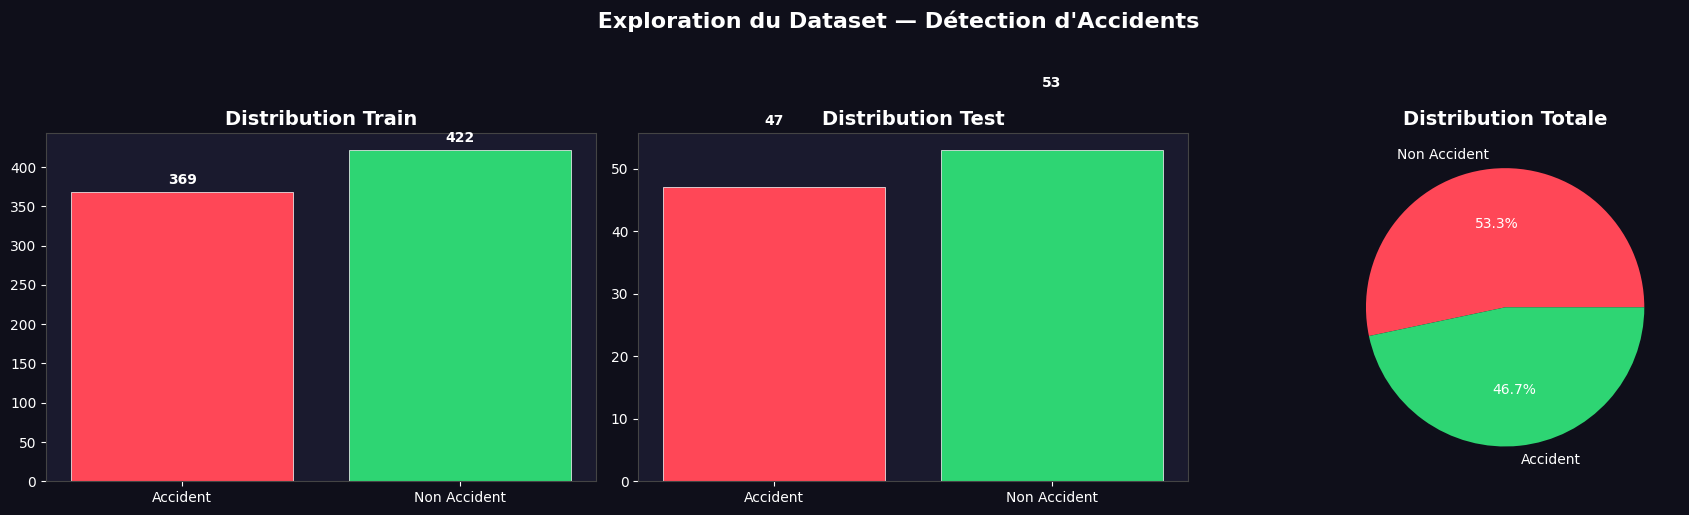

In [6]:
def count_images(directory):
    counts = {}
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            imgs = (glob.glob(os.path.join(cls_path, '*.jpg')) +
                    glob.glob(os.path.join(cls_path, '*.png')) +
                    glob.glob(os.path.join(cls_path, '*.jpeg')))
            counts[cls] = len(imgs)
    return counts

train_counts = count_images(CONFIG['TRAIN_DIR'])
test_counts  = count_images(CONFIG['TEST_DIR'])

print(' Distribution du dataset:')
print(f'  TRAIN: {train_counts}')
print(f'  TEST:  {test_counts}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, counts, title in zip(axes[:2],
                              [train_counts, test_counts],
                              ['Distribution Train', 'Distribution Test']):
    ax.set_facecolor('#1a1a2e')
    bars = ax.bar(counts.keys(), counts.values(),
                  color=['#ff4757','#2ed573'], edgecolor='white', linewidth=0.5)
    ax.set_title(title, color='white', fontsize=14, fontweight='bold')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#444')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                str(val), ha='center', color='white', fontweight='bold')

ax = axes[2]
ax.set_facecolor('#1a1a2e')
total = {cls: train_counts.get(cls,0)+test_counts.get(cls,0)
         for cls in set(list(train_counts)+list(test_counts))}
ax.pie(total.values(), labels=total.keys(),
       colors=['#ff4757','#2ed573'], autopct='%1.1f%%',
       textprops={'color':'white'})
ax.set_title('Distribution Totale', color='white', fontsize=14, fontweight='bold')

plt.suptitle(" Exploration du Dataset — Détection d'Accidents",
             color='white', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./eda_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

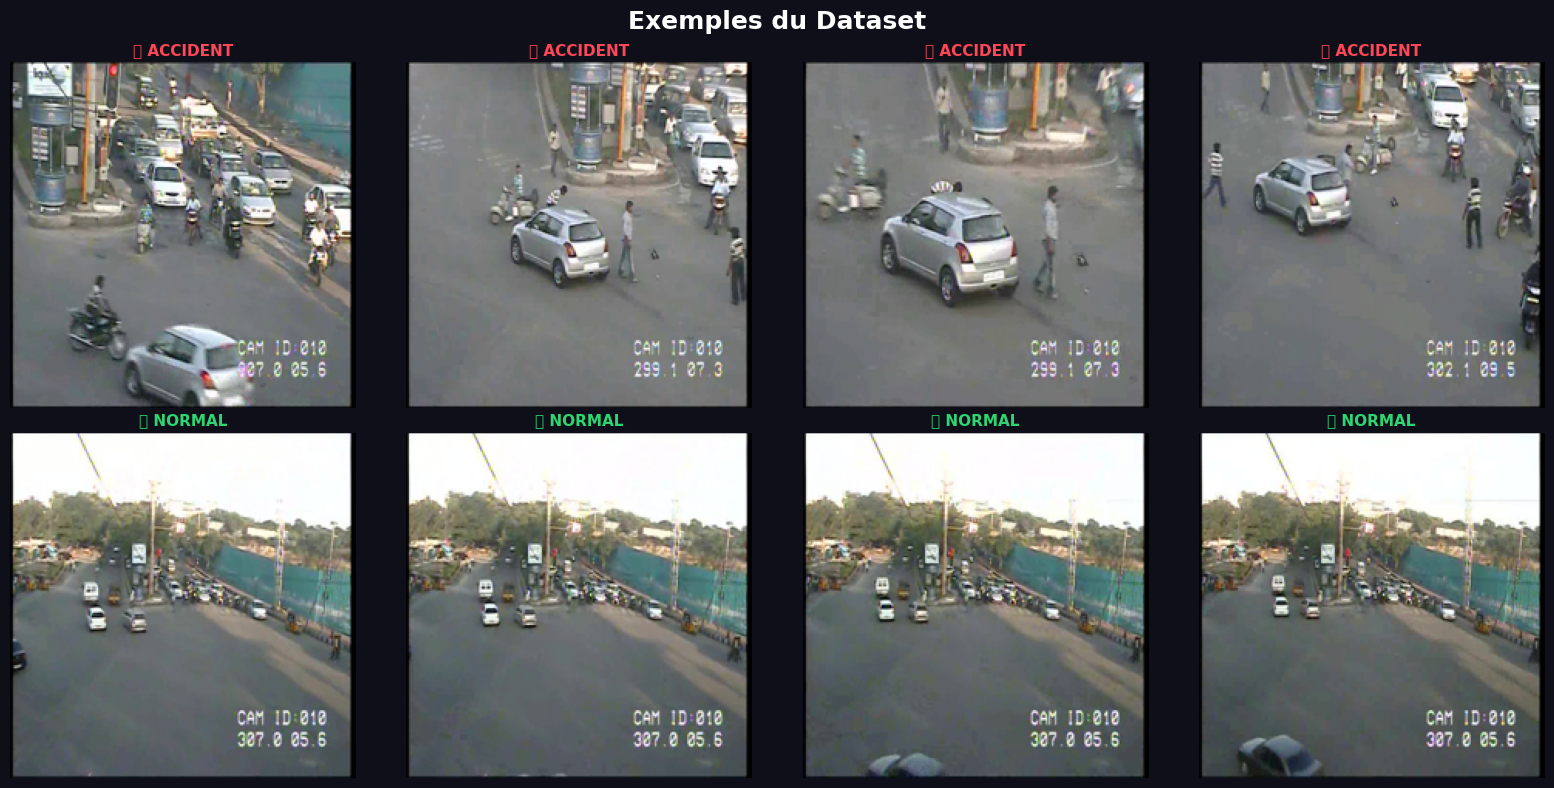

In [7]:
def show_sample_images(directory, n_per_class=4):
    classes = os.listdir(directory)
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(4*n_per_class, 4*len(classes)))
    fig.patch.set_facecolor('#0f0f1a')
    for row, cls in enumerate(classes):
        cls_path = os.path.join(directory, cls)
        imgs = (glob.glob(os.path.join(cls_path, '*.jpg')) +
                glob.glob(os.path.join(cls_path, '*.png')))[:n_per_class]
        for col, img_path in enumerate(imgs[:n_per_class]):
            ax = axes[row][col] if len(classes) > 1 else axes[col]
            img = Image.open(img_path).resize(CONFIG['IMG_SIZE'])
            ax.imshow(img); ax.set_facecolor('#1a1a2e'); ax.axis('off')
            is_acc = 'Accident' in cls and cls != 'Non Accident'
            ax.set_title('🚨 ACCIDENT' if is_acc else '✅ NORMAL',
                         color='#ff4757' if is_acc else '#2ed573',
                         fontweight='bold', fontsize=11)
    plt.suptitle('Exemples du Dataset', color='white', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./sample_images.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()

show_sample_images(CONFIG['TRAIN_DIR'])

## 🔄 Section 5 — Préparation des Données

> `create_generators()` est utilisé **par tous les modèles** (M1, M2, M3). Le `class_weight` est calculé **une seule fois** ici.

In [8]:
def create_generators(augmentation_level='basic'):
    """
    Crée les générateurs train / val / test partagés par tous les modèles.
    augmentation_level : 'none' | 'basic' | 'advanced'
    """
    kw = dict(
        target_size  = CONFIG['IMG_SIZE'],
        batch_size   = CONFIG['BATCH_SIZE'],
        class_mode   = 'binary',
        seed         = CONFIG['SEED'],
    )
    test_datagen = ImageDataGenerator(rescale=1./255)

    if augmentation_level == 'none':
        train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    elif augmentation_level == 'basic':
        train_datagen = ImageDataGenerator(
            rescale=1./255, validation_split=0.2,
            horizontal_flip=True, rotation_range=15, zoom_range=0.1,
            width_shift_range=0.1, height_shift_range=0.1,
            brightness_range=[0.8, 1.2], fill_mode='nearest')
    else:  # advanced
        train_datagen = ImageDataGenerator(
            rescale=1./255, validation_split=0.2,
            horizontal_flip=True, rotation_range=25, zoom_range=0.2,
            width_shift_range=0.15, height_shift_range=0.15,
            brightness_range=[0.7, 1.3], channel_shift_range=30,
            shear_range=0.1, fill_mode='reflect')

    train_gen = train_datagen.flow_from_directory(
        CONFIG['TRAIN_DIR'], subset='training',   shuffle=True,  **kw)
    val_gen   = train_datagen.flow_from_directory(
        CONFIG['TRAIN_DIR'], subset='validation', shuffle=False, **kw)
    test_gen  = test_datagen.flow_from_directory(
        CONFIG['TEST_DIR'],                       shuffle=False, **kw)

    print(f'  Classes : {train_gen.class_indices}')
    print(f'  Train / Val / Test : {train_gen.samples} / {val_gen.samples} / {test_gen.samples}')
    return train_gen, val_gen, test_gen

# Génération initiale (niveau 'basic' par défaut — peut être surchargé par modèle)
train_gen, val_gen, test_gen = create_generators('basic')
CONFIG['CLASS_INDICES'] = train_gen.class_indices

# ─── Class weights (calculé une seule fois) ──────────────────────────────────
class_weights_arr = compute_class_weight(
    'balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights = dict(enumerate(class_weights_arr))
print(f'\nClass Weights : {class_weights}')

Found 634 images belonging to 2 classes.
Found 157 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
  Classes : {'Accident': 0, 'Non Accident': 1}
  Train / Val / Test : 634 / 157 / 100

Class Weights : {0: np.float64(1.070945945945946), 1: np.float64(0.9378698224852071)}


## 🛠️ Section 6 — Fonctions Utilitaires

> `get_callbacks`, `evaluate_model`, `plot_training_history` et `plot_confusion_matrix` sont partagés par **tous les modèles**.

In [12]:
all_results = {}   # Dictionnaire commun pour stocker les résultats de tous les modèles

def get_callbacks(model_name, patience=5):
    return [
        callbacks.ModelCheckpoint(
            f'{CONFIG["MODELS_DIR"]}/{model_name}_best.h5',
            monitor='val_accuracy', save_best_only=True, verbose=0),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=patience,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice = 2*TP / (2*TP + FP + FN)
    Équivalent au F1-Score binaire — mesure le chevauchement entre
    prédictions et vérité terrain. smooth évite la division par zéro.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return float((2 * tp + smooth) / (2 * tp + fp + fn + smooth))


def evaluate_model(model, test_gen, model_name):
    """Évalue un modèle Keras et stocke les résultats dans all_results."""
    test_gen.reset()
    y_proba = model.predict(test_gen, verbose=0)
    y_pred  = (y_proba > 0.5).astype(int).flatten()
    y_true  = test_gen.classes
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    dice = dice_coefficient(y_true, y_pred)          # ← nouvelle ligne
    fpr, tpr, _ = roc_curve(y_true, y_proba.flatten())
    roc_auc = auc(fpr, tpr)
    result = dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                  auc=roc_auc, dice=dice,                      # ← dice ajouté
                  confusion_matrix=confusion_matrix(y_true, y_pred),
                  fpr=fpr, tpr=tpr)
    all_results[model_name] = result
    print(f'\n{"="*52}')
    print(f'   {model_name}')
    print(f'{"="*52}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec:.4f}   Recall : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}   AUC    : {roc_auc:.4f}')
    print(f'  Dice Coef : {dice:.4f}')                         # ← nouvelle ligne
    print(f'{"="*52}')
    return result

def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f1a')
    fig.suptitle(f' {model_name}', color='white', fontsize=14, fontweight='bold')
    for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.set_facecolor('#1a1a2e')
        ax.plot(history.history[metric],           color='#2ed573', lw=2, label='Train')
        ax.plot(history.history[f'val_{metric}'],  color='#ff4757', lw=2, ls='--', label='Val')
        ax.set_title(ylabel, color='white')
        ax.set_xlabel('Epoch', color='#aaa'); ax.set_ylabel(ylabel, color='#aaa')
        ax.legend(facecolor='#2a2a3e', labelcolor='white')
        ax.tick_params(colors='white')
        ax.grid(alpha=0.2, color='#555')
        for sp in ax.spines.values(): sp.set_color('#444')
    plt.tight_layout()
    plt.savefig(f'./{model_name.replace(" ","_")}_history.png',
                dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()

def plot_confusion_matrix(cm, model_name):
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor('#0f0f1a'); ax.set_facecolor('#1a1a2e')
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
                xticklabels=['Accident','Normal'],
                yticklabels=['Accident','Normal'], ax=ax)
    ax.set_title(f'{model_name} — Matrice de Confusion',
                 color='white', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prédit', color='#aaa'); ax.set_ylabel('Réel', color='#aaa')
    ax.tick_params(colors='white')
    plt.tight_layout()
    plt.savefig(f'./{model_name.replace(" ","_")}_cm.png',
                dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()

print(' Fonctions utilitaires chargées!')

 Fonctions utilitaires chargées!


## 🏗️ Section 7 — Modèle 1 : CNN Simple (Baseline)

> 3 blocs Conv2D → MaxPool → Dense(256) → Sigmoid. Pas d'augmentation pour évaluer la baseline pure.

In [10]:
def build_model1(input_shape=(*CONFIG['IMG_SIZE'], 3)):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ], name='CNN_Simple')
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

model1 = build_model1()
model1.summary()
print(f'\nParamètres : {model1.count_params():,}')

Model: "CNN_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,244,929 (84.86 MB)

 Trainable params: 22,244,929 (84.86 MB)

 Non-trainable params: 0 (0.00 B)


Paramètres : 22,244,929


 Entraînement Modèle 1 — CNN Simple (sans augmentation)
Found 634 images belonging to 2 classes.
Found 157 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
  Classes : {'Accident': 0, 'Non Accident': 1}
  Train / Val / Test : 634 / 157 / 100
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.6048 - loss: 0.6498

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 631ms/step - accuracy: 0.6609 - loss: 0.6337 - val_accuracy: 0.4650 - val_loss: 0.8409 - learning_rate: 5.0000e-04
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 537ms/step - accuracy: 0.7287 - loss: 0.5791 - val_accuracy: 0.2611 - val_loss: 0.8806 - learning_rate: 5.0000e-04
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 503ms/step - accuracy: 0.7618 - loss: 0.5032 - val_accuracy: 0.3949 - val_loss: 1.2463 - learning_rate: 5.0000e-04
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8063 - loss: 0.4629
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 576ms/step - accuracy: 0.8328 - loss: 0.4272 - val_accuracy: 0.2675 - val_loss: 1.5093 - learning_rate: 5.0000e-04
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 523ms/step - accuracy: 0.8502 - loss: 0.3497 - val_accuracy: 0.4522 - val_loss: 1.9586 - learning_rate: 2.5000e-04
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - accuracy: 0.8612 - l

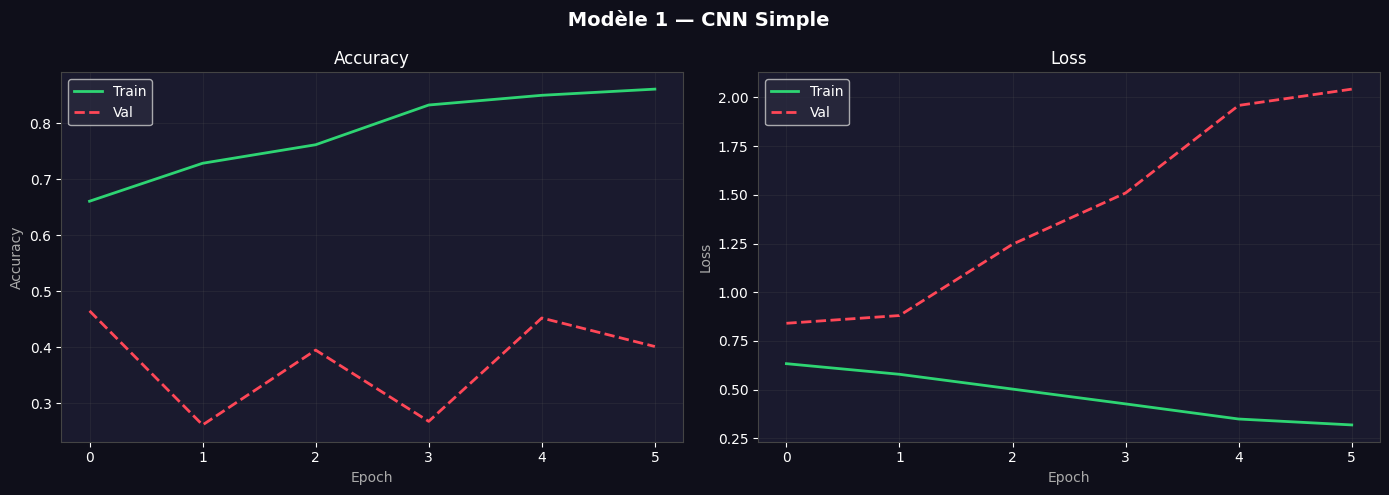


   M1 — CNN Simple
  Accuracy  : 72.00%
  Precision : 0.8571   Recall : 0.5660
  F1-Score  : 0.6818   AUC    : 0.7174
  Dice Coef : 0.6818


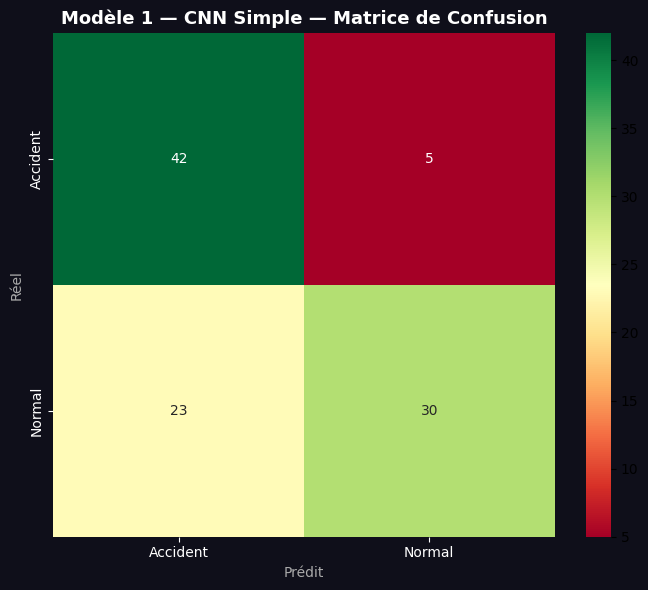

In [13]:
print(' Entraînement Modèle 1 — CNN Simple (sans augmentation)')
train_gen1, val_gen1, test_gen1 = create_generators('none')
start = time.time()
history1 = model1.fit(
    train_gen1, validation_data=val_gen1,
    epochs=CONFIG['EPOCHS'],
    callbacks=get_callbacks('m1'),
    class_weight=class_weights,
    verbose=1
)
print(f'Temps : {time.time()-start:.1f}s')
plot_training_history(history1, 'Modèle 1 — CNN Simple')
result1 = evaluate_model(model1, test_gen1, 'M1 — CNN Simple')
plot_confusion_matrix(result1['confusion_matrix'], 'Modèle 1 — CNN Simple')

## 🏗️ Section 8 — Modèle 2 : VGG16 (Transfer Learning)

> VGG16 pré-entraîné sur ImageNet — fine-tuning complet. Utilise les **mêmes générateurs** (`create_generators`) et le **même `class_weights`** que M1.

In [14]:
def build_model2_vgg16(input_shape=(*CONFIG['IMG_SIZE'], 3)):
    """VGG16 pré-entraîné — excellent pour détecter textures (débris, fumée)."""
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True  # Fine-tuning complet avec lr très faible

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ], name='VGG16_FineTuned')
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),  # LR faible pour ne pas écraser les poids
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model2 = build_model2_vgg16()
model2.summary()
print(f'\nParamètres : {model2.count_params():,}')

Model: "VGG16_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 21,137,729 (80.63 MB)

 Non-trainable params: 0 (0.00 B)


Paramètres : 21,137,729


 Entraînement Modèle 2 — VGG16 (Transfer Learning)
Found 634 images belonging to 2 classes.
Found 157 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
  Classes : {'Accident': 0, 'Non Accident': 1}
  Train / Val / Test : 634 / 157 / 100
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5602 - loss: 0.7225

20/20 ━━━━━━━━━━━━━━━━━━━━ 108s 5s/step - accuracy: 0.5678 - loss: 0.7047 - val_accuracy: 0.4586 - val_loss: 0.7803 - learning_rate: 1.0000e-05
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5847 - loss: 0.6911

20/20 ━━━━━━━━━━━━━━━━━━━━ 108s 5s/step - accuracy: 0.5994 - loss: 0.6862 - val_accuracy: 0.4904 - val_loss: 0.7514 - learning_rate: 1.0000e-05
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.6467 - loss: 0.6193 - val_accuracy: 0.4777 - val_loss: 0.7634 - learning_rate: 1.0000e-05
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 105s 5s/step - accuracy: 0.6924 - loss: 0.5949 - val_accuracy: 0.3885 - val_loss: 0.8449 - learning_rate: 1.0000e-05
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6883 - loss: 0.5627


Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.7082 - loss: 0.5442 - val_accuracy: 0.5096 - val_loss: 0.8099 - learning_rate: 1.0000e-05
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.7587 - loss: 0.4908 - val_accuracy: 0.4841 - val_loss: 0.8896 - learning_rate: 5.0000e-06
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.7508 - loss: 0.4863 - val_accuracy: 0.4777 - val_loss: 0.9190 - learning_rate: 5.0000e-06
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7617 - loss: 0.4601
Epoch 8: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
20/20 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.7729 - loss: 0.4451 - val_accuracy: 0.4331 - val_loss: 1.0305 - learning_rate: 5.0000e-06
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 103s 5s/step - accuracy: 0.7808 - loss: 0.4416 - val_accuracy: 0.4777 - val_loss: 1.0056 - learning_rate: 2.5000e-06
Epoch 10/20

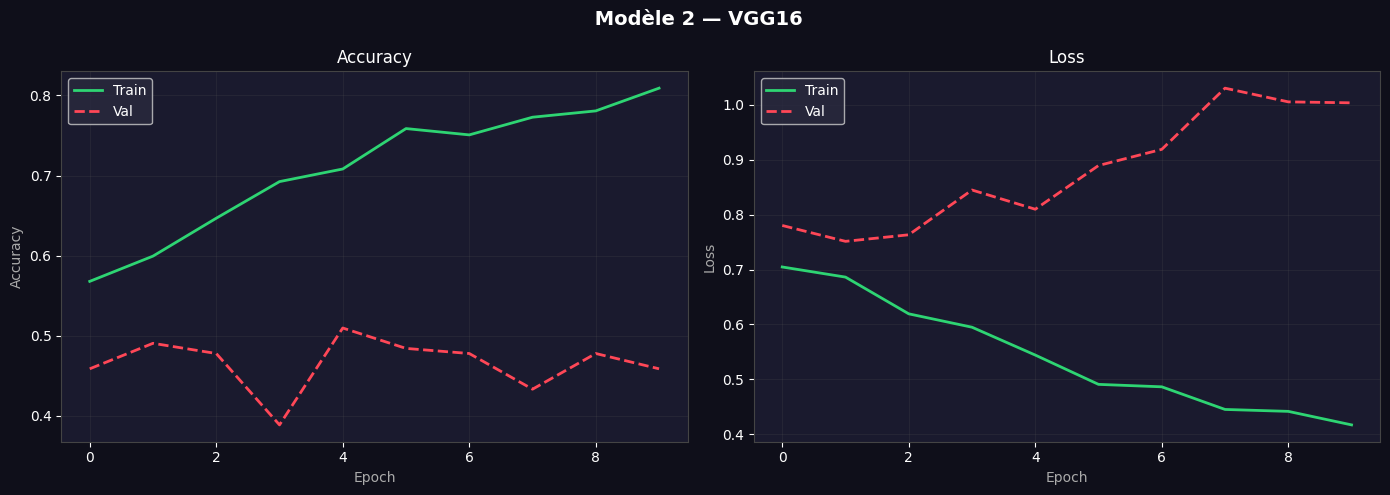


   M2 — VGG16
  Accuracy  : 67.00%
  Precision : 0.7000   Recall : 0.6604
  F1-Score  : 0.6796   AUC    : 0.7852
  Dice Coef : 0.6796


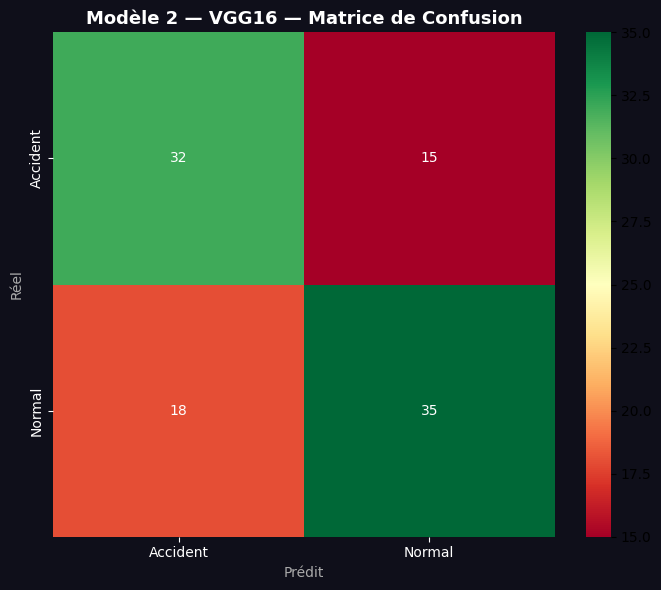

In [16]:
print(' Entraînement Modèle 2 — VGG16 (Transfer Learning)')
train_gen2, val_gen2, test_gen2 = create_generators('basic')  # Augmentation basique
start = time.time()
history2 = model2.fit(
    train_gen2, validation_data=val_gen2,
    epochs=CONFIG['EPOCHS'],
    callbacks=get_callbacks('m2'),
    class_weight=class_weights,    # Même class_weights que M1
    verbose=1
)
print(f' Temps : {time.time()-start:.1f}s')
plot_training_history(history2, 'Modèle 2 — VGG16')
result2 = evaluate_model(model2, test_gen2, 'M2 — VGG16')
plot_confusion_matrix(result2['confusion_matrix'], 'Modèle 2 — VGG16')

##  Section 9 — Modèle 3 : YOLOv8 (Classification)



In [23]:
from ultralytics import YOLO
import torch

print(f'  GPU disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')

# ─── Préparation de la structure YOLO ────────────────────────────────────────
YOLO_DATA_DIR = Path('./data_yolo')
SOURCE_DIR    = Path('./data')

def prepare_yolo_dataset(source_dir: Path, yolo_dir: Path, val_split: float = 0.15):
    """Réorganise le dataset en structure train/val/test pour YOLO."""
    random.seed(CONFIG['SEED'])
    yolo_dir.mkdir(parents=True, exist_ok=True)
    has_splits = (source_dir / 'train').exists()
    classes = [d.name for d in (source_dir / ('train' if has_splits else '')).iterdir()
               if d.is_dir()]
    print(f'  Classes détectées : {classes}')

    for split_src in (['train', 'test'] if has_splits else ['all']):
        for cls in classes:
            src_path = (source_dir / split_src / cls) if has_splits else (source_dir / cls)
            if not src_path.exists():
                continue
            images = (list(src_path.glob('*.jpg')) +
                      list(src_path.glob('*.png')) +
                      list(src_path.glob('*.jpeg')))
            if split_src == 'test':
                dst = yolo_dir / 'test' / cls
                dst.mkdir(parents=True, exist_ok=True)
                for img in images:
                    shutil.copy2(img, dst / img.name)
            else:
                random.shuffle(images)
                n_val = max(1, int(len(images) * val_split))
                for subset, imgs in [('val', images[:n_val]), ('train', images[n_val:])]:
                    dst = yolo_dir / subset / cls
                    dst.mkdir(parents=True, exist_ok=True)
                    for img in imgs:
                        shutil.copy2(img, dst / img.name)

    print('\n Dataset YOLO préparé :')
    for split in ['train', 'val', 'test']:
        for cls in classes:
            p = yolo_dir / split / cls
            n = len(list(p.glob('*.*'))) if p.exists() else 0
            print(f'  {split}/{cls}: {n} images')
    return classes

CLASSES = prepare_yolo_dataset(SOURCE_DIR, YOLO_DATA_DIR)
print(f'\n Dataset prêt : {YOLO_DATA_DIR}')

  GPU disponible : False
  Classes détectées : ['Accident', 'Non Accident']

 Dataset YOLO préparé :
  train/Accident: 314 images
  train/Non Accident: 359 images
  val/Accident: 55 images
  val/Non Accident: 63 images
  test/Accident: 47 images
  test/Non Accident: 53 images

 Dataset prêt : data_yolo


In [39]:
print(' Entraînement YOLOv8 (Classification)...')
YOLO8_RUN_NAME = 'yolov8_accident'
model_yolo = YOLO('yolov8s-cls.pt')

start = time.time()
results_yolo = model_yolo.train(
    data     = str(YOLO_DATA_DIR),
    task     = 'classify',
    epochs   = CONFIG['EPOCHS'],          # Cohérence avec M1 et M2
    imgsz    = CONFIG['IMG_SIZE'][0],     # 224 — cohérence avec M1 et M2
    batch    = CONFIG['BATCH_SIZE'] // 2, # 16 (YOLO plus gourmand en mémoire)
    lr0      = 1e-3,
    patience = 10,
    save     = True,
    plots    = True,
    name     = YOLO8_RUN_NAME,
    exist_ok = True,
    device   = 0 if torch.cuda.is_available() else 'cpu',
    workers  = 2,
    amp      = torch.cuda.is_available(),
    verbose  = True,
    seed     = CONFIG['SEED'],
)
yolo_train_time = time.time() - start
print(f' Temps : {yolo_train_time:.1f}s')

 Entraînement YOLOv8 (Classification)...
Ultralytics 8.4.36  Python-3.12.6 torch-2.10.0+cpu CPU (11th Gen Intel Core i7-11800H @ 2.30GHz)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_yolo, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_accident, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

🔍 Évaluation sur le jeu de test...

   M3 — YOLOv8s
  Accuracy  : 94.00%
  Precision : 0.9273   Recall : 0.9623
  F1-Score  : 0.9444   AUC    : 0.0132
  Dice Coef : 0.9444

              precision    recall  f1-score   support

    Accident       0.96      0.91      0.93        47
Non Accident       0.93      0.96      0.94        53

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



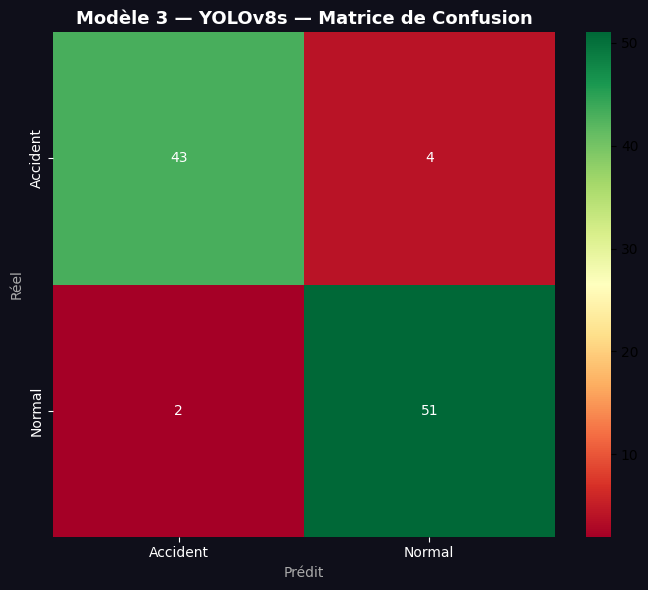

In [40]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice = 2*TP / (2*TP + FP + FN) — équivalent F1 binaire."""
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return float((2*tp + smooth) / (2*tp + fp + fn + smooth))

def evaluate_yolo(model, test_dir: Path, classes: list):
    """Évalue YOLOv8 et stocke les résultats dans all_results (même format que M1/M2)."""
    y_true, y_pred, y_proba = [], [], []
    class_to_idx = {cls: i for i, cls in enumerate(sorted(classes))}

    print('🔍 Évaluation sur le jeu de test...')
    for cls in sorted(classes):
        cls_path = test_dir / cls
        images = (list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.png')) +
                  list(cls_path.glob('*.jpeg'))) if cls_path.exists() else []
        for img_path in images:
            res      = model.predict(str(img_path), verbose=False)[0]
            pred_idx = int(res.probs.top1)
            pred_name = res.names[pred_idx]
            y_true.append(class_to_idx[cls])
            y_pred.append(class_to_idx.get(pred_name, pred_idx))
            acc_idx = {v: k for k, v in res.names.items()}.get('Accident', 0)
            y_proba.append(float(res.probs.data[acc_idx]))

    y_true, y_pred, y_proba = map(np.array, [y_true, y_pred, y_proba])
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    dice = dice_coefficient(y_true, y_pred)
    try:    roc_auc_val = roc_auc_score(y_true, y_proba)
    except: roc_auc_val = 0.0
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    cm = confusion_matrix(y_true, y_pred)

    result = dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                  auc=roc_auc_val, dice=dice, fpr=fpr, tpr=tpr,
                  confusion_matrix=cm)
    all_results['M3 — YOLOv8s'] = result

    print(f'\n{"="*52}')
    print(f'   M3 — YOLOv8s')
    print(f'{"="*52}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec:.4f}   Recall : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}   AUC    : {roc_auc_val:.4f}')
    print(f'  Dice Coef : {dice:.4f}')
    print(f'{"="*52}')
    print(f'\n{classification_report(y_true, y_pred, target_names=sorted(classes))}')
    return result

best_yolo_path = Path(results_yolo.save_dir) / 'weights' / 'best.pt'
best_yolo = YOLO(str(best_yolo_path))
result3 = evaluate_yolo(best_yolo, YOLO_DATA_DIR / 'test', CLASSES)
plot_confusion_matrix(result3['confusion_matrix'], 'Modèle 3 — YOLOv8s')

## 📊 Section 10 — Comparaison Finale des 3 Modèles

In [44]:
rows = [(n, r['accuracy'], r['precision'], r['recall'],
         r['f1'], r['dice'])                    # ← dice ajouté
        for n, r in all_results.items()]
df = (pd.DataFrame(rows,
      columns=['Modèle','Accuracy','Precision','Recall','F1','Dice'])
      .sort_values('F1', ascending=False)
      .reset_index(drop=True))
df.index += 1
print('\n CLASSEMENT FINAL')
print('='*90)
print(df.to_string(float_format='{:.4f}'.format))
print('='*90)


 CLASSEMENT FINAL
            Modèle  Accuracy  Precision  Recall     F1   Dice
1     M3 — YOLOv8s    0.9400     0.9273  0.9623 0.9444 0.9444
2  M1 — CNN Simple    0.7200     0.8571  0.5660 0.6818 0.6818
3       M2 — VGG16    0.6700     0.7000  0.6604 0.6796 0.6796


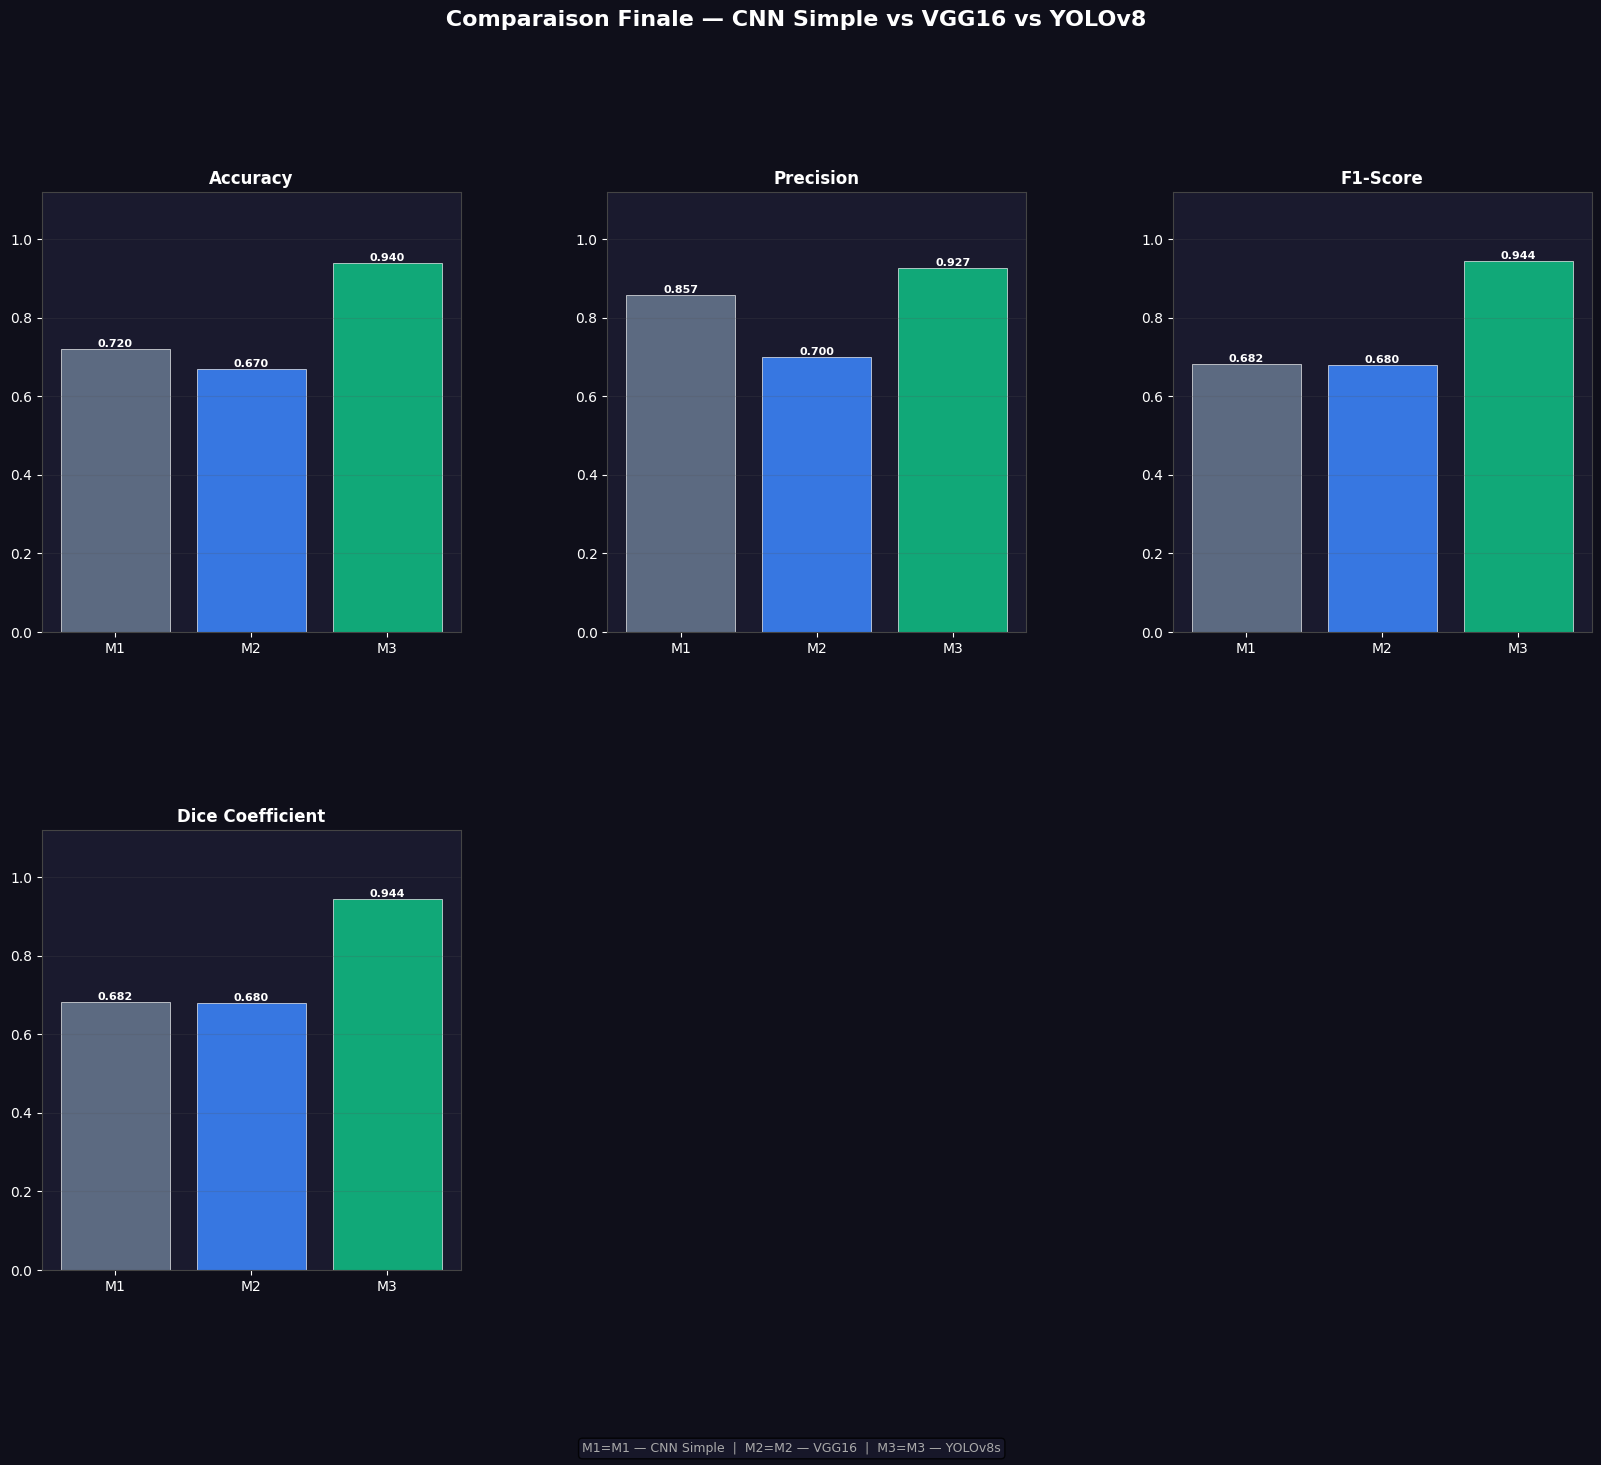

In [ ]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0f0f1a')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
metrics = ['accuracy', 'precision', 'f1', 'dice'] 
labels  = ['Accuracy', 'Precision', 'F1-Score', 'Dice Coefficient']
names   = list(all_results.keys())
palette = ['#64748b', '#3b82f6', '#10b981']

for idx, (metric, label) in enumerate(zip(metrics, labels)):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor('#1a1a2e')
    vals = [all_results[n][metric] for n in names]
    bars = ax.bar([f'M{i+1}' for i in range(len(names))], vals,
                  color=palette[:len(names)], edgecolor='white', linewidth=0.5, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', color='white', fontsize=8, fontweight='bold')
    ax.set_title(label, color='white', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.12); ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#444')
    ax.grid(axis='y', alpha=0.2, color='#555')

leg = '  |  '.join([f'M{i+1}={n}' for i, n in enumerate(names)])
fig.text(0.5, -0.02, leg, ha='center', color='#aaa', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8))
fig.suptitle(" Comparaison Finale — CNN Simple vs VGG16 vs YOLOv8",
             color='white', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('./comparaison_finale.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 💾 Section 11 — Sauvegarde du Meilleur Modèle

In [49]:
# ─── Meilleur modèle Keras (M1 ou M2) ───────────────────────────────────────
keras_model_map = {
    'M1 — CNN Simple' : model1,
    'M2 — VGG16'      : model2,
    'M3 — YOLOv8s'     : best_yolo
}
dl_results = {k: v for k, v in all_results.items() if k in keras_model_map}
best_name  = max(dl_results, key=lambda x: dl_results[x]['f1'])
best_model = keras_model_map[best_name]
best_r     = all_results[best_name]

print(f' Meilleur modèle Keras : {best_name}')
print(f'   F1-Score : {best_r["f1"]:.4f}')
print(f'   Accuracy : {best_r["accuracy"]*100:.2f}%')

best_model.save('./saved_models/best_accident_detector.h5')
print('\n Modèle → ./saved_models/best_accident_detector.h5')

# ─── Métadonnées ─────────────────────────────────────────────────────────────
metadata = {
    'model_name'   : best_name,
    'input_size'   : list(CONFIG['IMG_SIZE']),
    'classes'      : CONFIG['CLASSES'],
    'class_indices': CONFIG['CLASS_INDICES'],
    'best_metrics' : {k: round(float(best_r[k]), 4)
                      for k in ['accuracy', 'f1', 'precision', 'auc']},
    'all_results'  : {
        n: {k: float(v) for k, v in r.items()
            if k not in ['confusion_matrix', 'fpr', 'tpr']
            and isinstance(v, (int, float, np.floating, np.integer))}
        for n, r in all_results.items()
    }
}
with open('./saved_models/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(' Métadonnées → ./saved_models/metadata.json')

print('\n Fichiers sauvegardés :')
for fname in sorted(os.listdir('./saved_models')):
    sz = os.path.getsize(f'./saved_models/{fname}') / 1024
    print(f'  {fname:<45} {sz:>8.1f} KB')

 Meilleur modèle Keras : M3 — YOLOv8s
   F1-Score : 0.9444
   Accuracy : 94.00%

 Modèle → ./saved_models/best_accident_detector.h5
 Métadonnées → ./saved_models/metadata.json

 Fichiers sauvegardés :
  best_accident_detector.h5                       9961.5 KB
  m1_best.h5                                    260729.0 KB
  m2_best.h5                                    247806.7 KB
  metadata.json                                      1.0 KB


In [54]:
import shutil, os
os.makedirs('./saved_models', exist_ok=True)

best_pt = Path(results_yolo.save_dir) / 'weights' / 'best.pt'
shutil.copy(best_pt, './saved_models/best_yolo.pt')
print(f' Modèle copié → ./saved_models/best_yolo.pt')

 Modèle copié → ./saved_models/best_yolo.pt


## 🔍 Section 12 — Prédiction sur une Image

 Image  : ./data/test\Accident\test12_13.jpg
  Réel   : Accident

  P(Accident)  : 99.7%
  P(Normal)    : 0.3%
  →  ACCIDENT DÉTECTÉ  (confiance 99.7%)


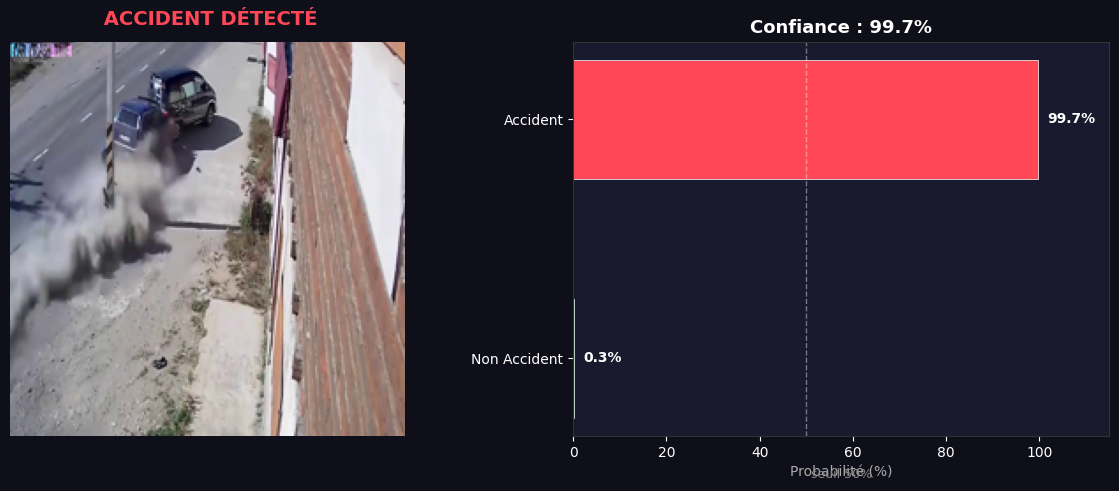


❌ Incorrect — Prédit : Non Accident | Réel : Accident


In [52]:
def predict_image_yolo(image_path, model_yolo):
    """Prédit avec YOLOv8 classification."""
    img = Image.open(image_path).convert('RGB').resize(CONFIG['IMG_SIZE'])

    res          = model_yolo.predict(str(image_path), verbose=False)[0]  # bool, pas int
    accident_idx = {v: k for k, v in res.names.items()}.get('Accident', 0)
    accident_proba = float(res.probs.data[accident_idx])
    normal_proba   = 1.0 - accident_proba
    is_accident    = accident_proba > 0.5
    label          = ' ACCIDENT DÉTECTÉ' if is_accident else ' PAS D\'ACCIDENT'
    confidence     = accident_proba if is_accident else normal_proba

    print(f'  P(Accident)  : {accident_proba*100:.1f}%')
    print(f'  P(Normal)    : {normal_proba*100:.1f}%')
    print(f'  → {label}  (confiance {confidence*100:.1f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#0f0f1a')
    axes[0].imshow(img); axes[0].axis('off')
    axes[0].set_title(label, color='#ff4757' if is_accident else '#2ed573',
                      fontsize=14, fontweight='bold', pad=12)

    ax = axes[1]; ax.set_facecolor('#1a1a2e')
    for sp in ax.spines.values(): sp.set_color('#333')
    bars = ax.barh(['Non Accident', 'Accident'],
                   [normal_proba*100, accident_proba*100],
                   color=['#2ed573', '#ff4757'], edgecolor='white', linewidth=0.5, height=0.5)
    ax.set_xlim(0, 115); ax.set_xlabel('Probabilité (%)', color='#aaa')
    ax.tick_params(colors='white')
    ax.set_title(f'Confiance : {confidence*100:.1f}%', color='white', fontsize=13, fontweight='bold')
    for bar, p in zip(bars, [normal_proba, accident_proba]):
        ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                f'{p*100:.1f}%', va='center', color='white', fontweight='bold')
    ax.axvline(50, color='white', ls='--', lw=1, alpha=0.4)
    ax.text(51, -0.5, 'seuil 50%', color='#888', fontsize=9)
    plt.tight_layout()
    plt.savefig('./prediction_result_yolo.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    return label, confidence * 100


# ── Test ─────────────────────────────────────────────────────────────────────
test_images = glob.glob(os.path.join(CONFIG['TEST_DIR'], '**', '*.jpg'), recursive=True)
if test_images:
    sample_img   = random.choice(test_images)
    ground_truth = 'Accident' if 'Accident' in sample_img and 'Non' not in sample_img else 'Non Accident'
    print(f' Image  : {sample_img}')
    print(f'  Réel   : {ground_truth}\n')
    label, conf = predict_image_yolo(sample_img, best_yolo)   # best_yolo, pas best_model
    predicted   = 'Accident' if '🚨' in label else 'Non Accident'
    status      = ' Correct' if predicted == ground_truth else '❌ Incorrect'
    print(f'\n{status} — Prédit : {predicted} | Réel : {ground_truth}')